<div style="text-align: center; background-color: #e0e0e0; border: 2px solid #888888; border-radius: 10px; padding: 15px; margin: 20px 0;">
  <h2 style="color: #222222; font-family: Arial, sans-serif;">1. Exploratory Data Analysis</h2>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')

In [3]:
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\nTrain Info:")
print(train.info())
print("\nMissing Values:")
print(train.isnull().sum())

Train Shape: (593994, 13)
Test Shape: (254569, 12)

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memor

In [5]:
train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [6]:
display(train.describe(include='object').T)

,count,unique,top,freq
gender,593994,3,Female,306175
marital_status,593994,4,Single,288843
education_level,593994,5,Bachelor's,279606
employment_status,593994,5,Employed,450645
loan_purpose,593994,8,Debt consolidation,324695
grade_subgrade,593994,30,C3,58695


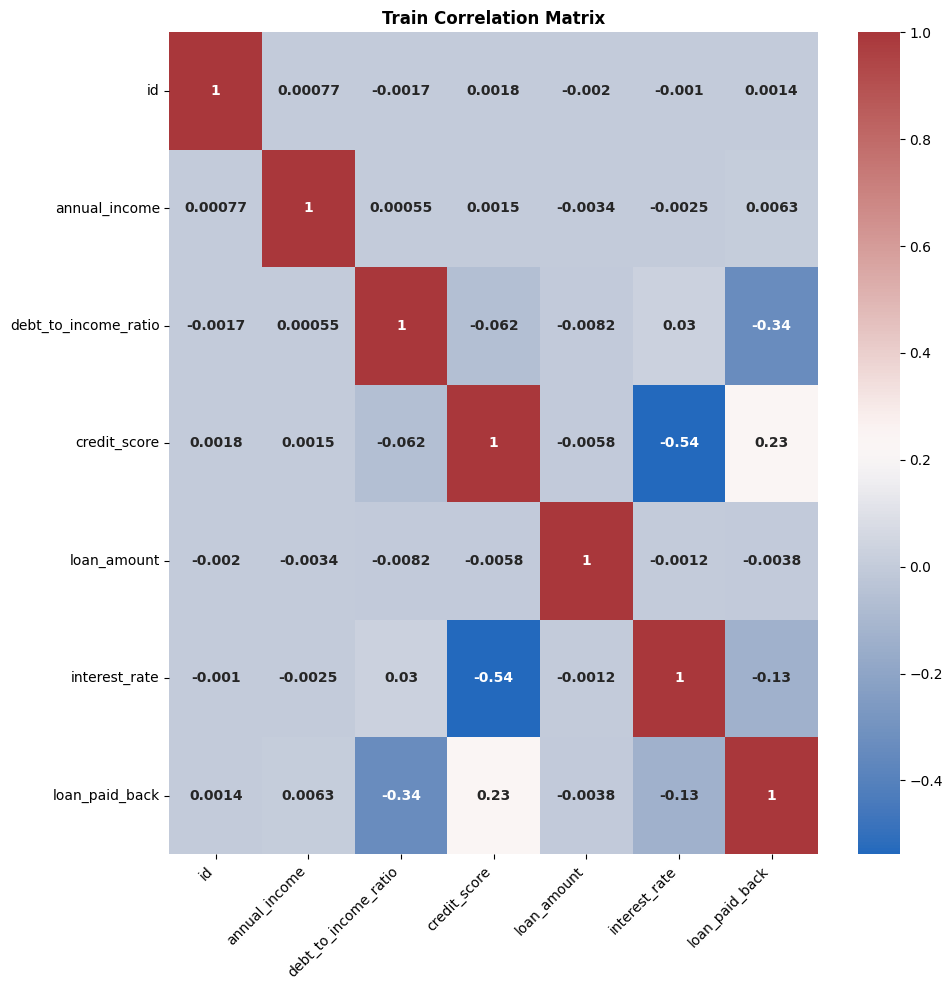

In [7]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(10,10))
sns.heatmap(corr, cmap='vlag', annot=True, annot_kws={'weight':'bold'})
plt.title('Train Correlation Matrix', weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

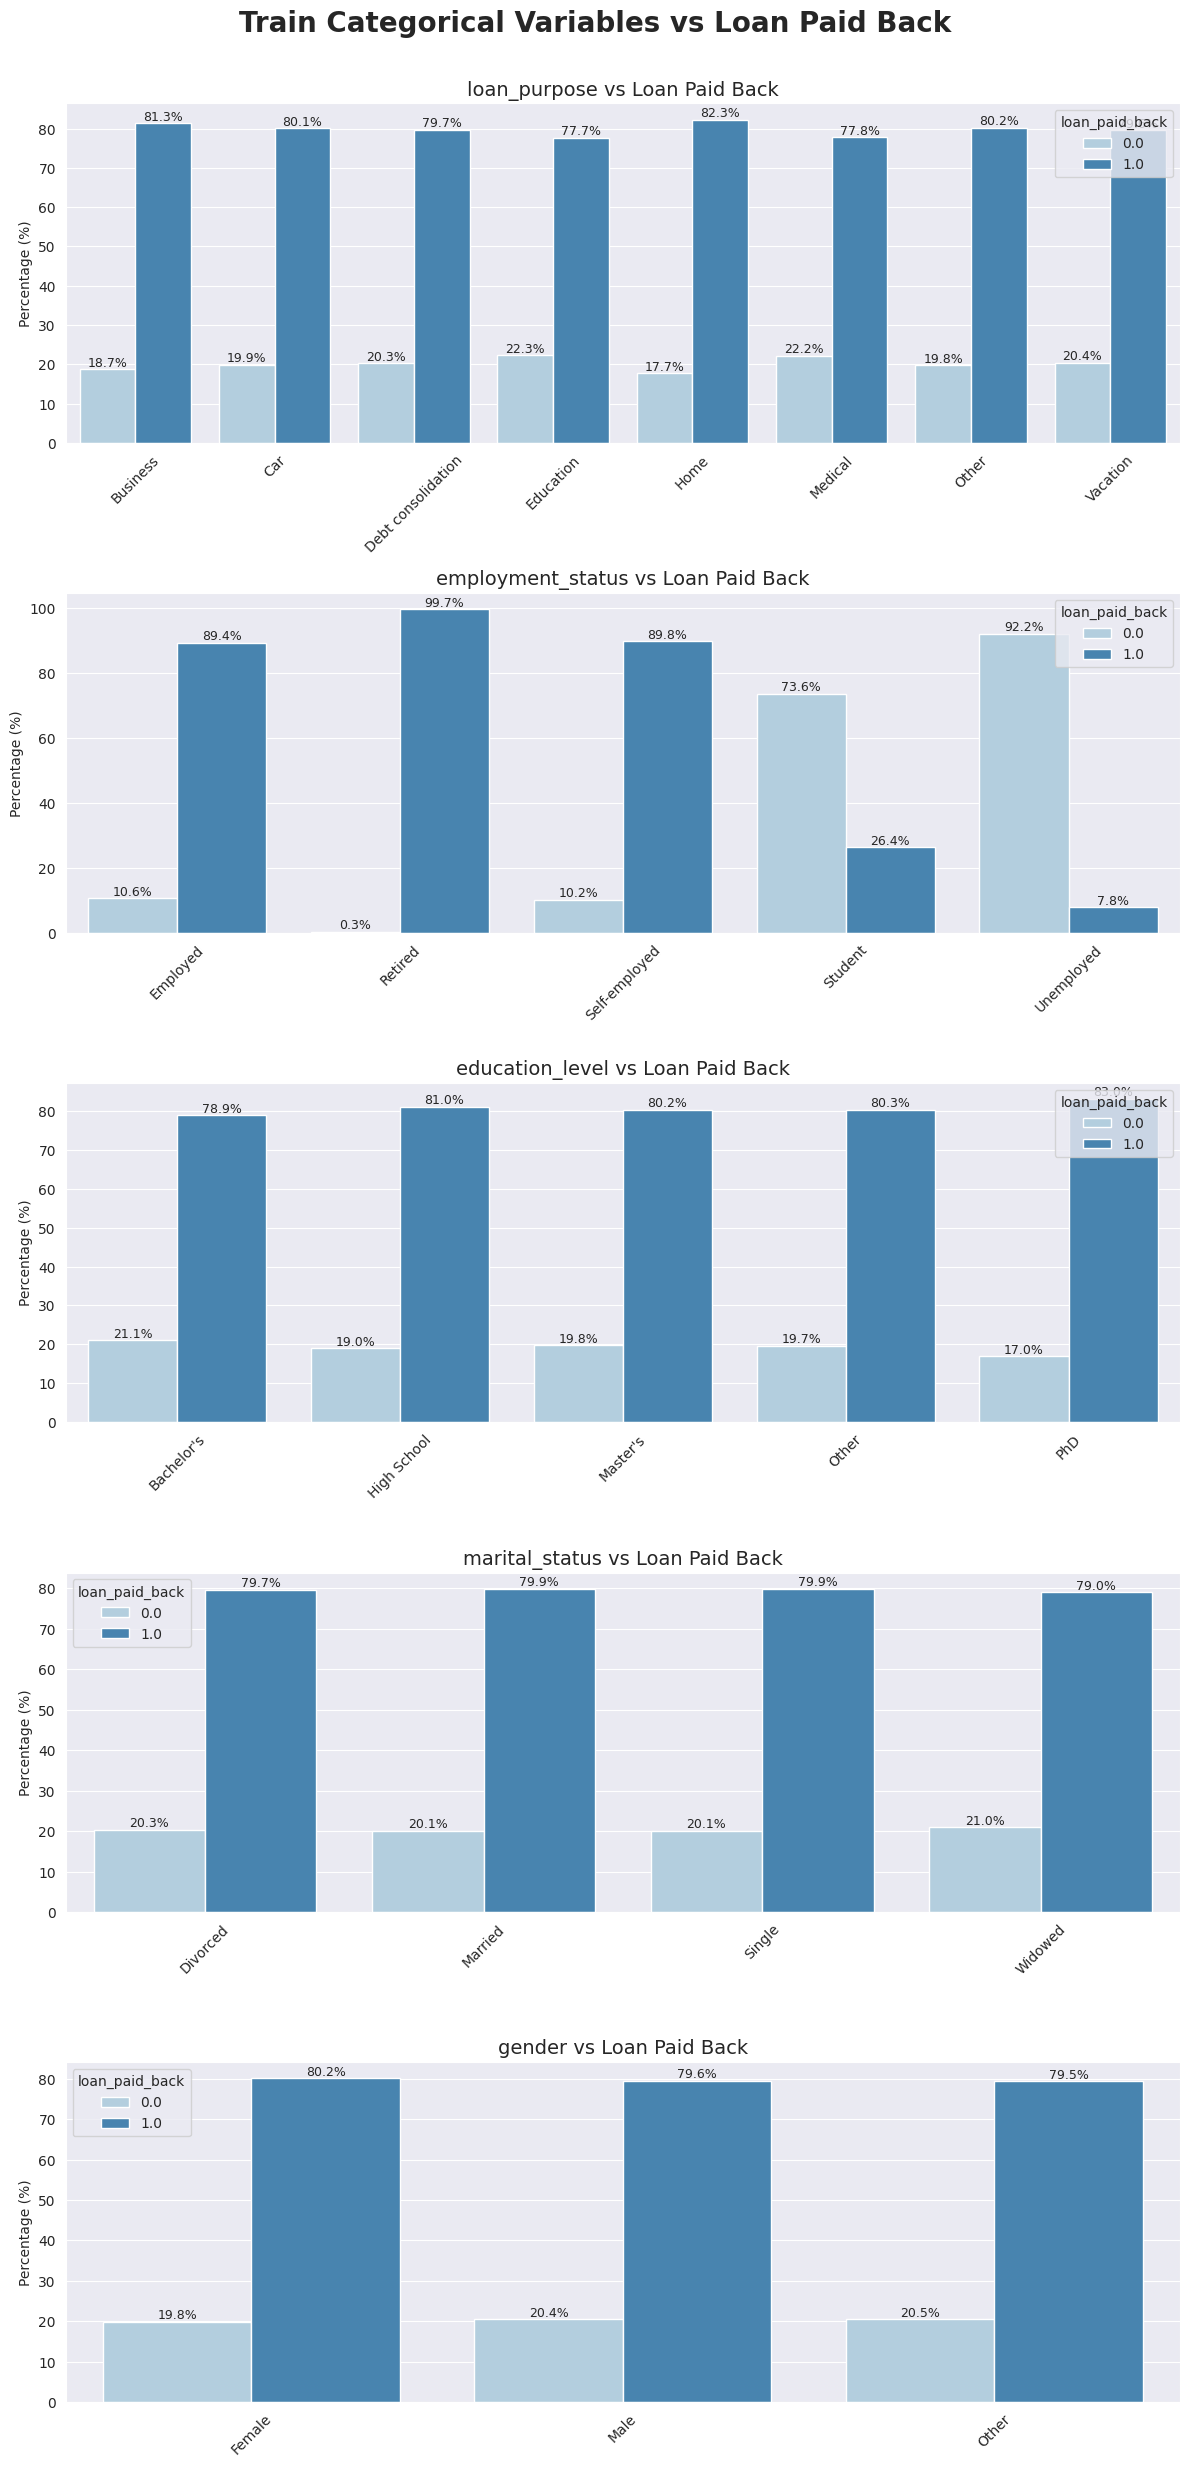

In [8]:
cat_cols = ['loan_purpose', 'employment_status', 'education_level', 'marital_status', 'gender']
sns.set_style("darkgrid")
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 5*len(cat_cols)))
plt.subplots_adjust(hspace=0.4)
fig.suptitle('Train Categorical Variables vs Loan Paid Back', fontsize=20, weight='bold', y=0.995)

for i, col in enumerate(cat_cols):
  
    train_perc = (
        train.groupby(col)['loan_paid_back']
        .value_counts(normalize=True)
        .mul(100)
        .rename('Percentage')
        .reset_index()
    )
 
    sns.barplot(
        x=col, y='Percentage', hue='loan_paid_back',
        data=train_perc, ax=axes[i], palette='Blues'
    )
    
    axes[i].set_title(f"{col} vs Loan Paid Back", fontsize=14)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
 
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(f'{height:.1f}%',
                             (p.get_x() + p.get_width() / 2, height),
                             ha='center', va='bottom',
                             fontsize=9)

plt.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.show()

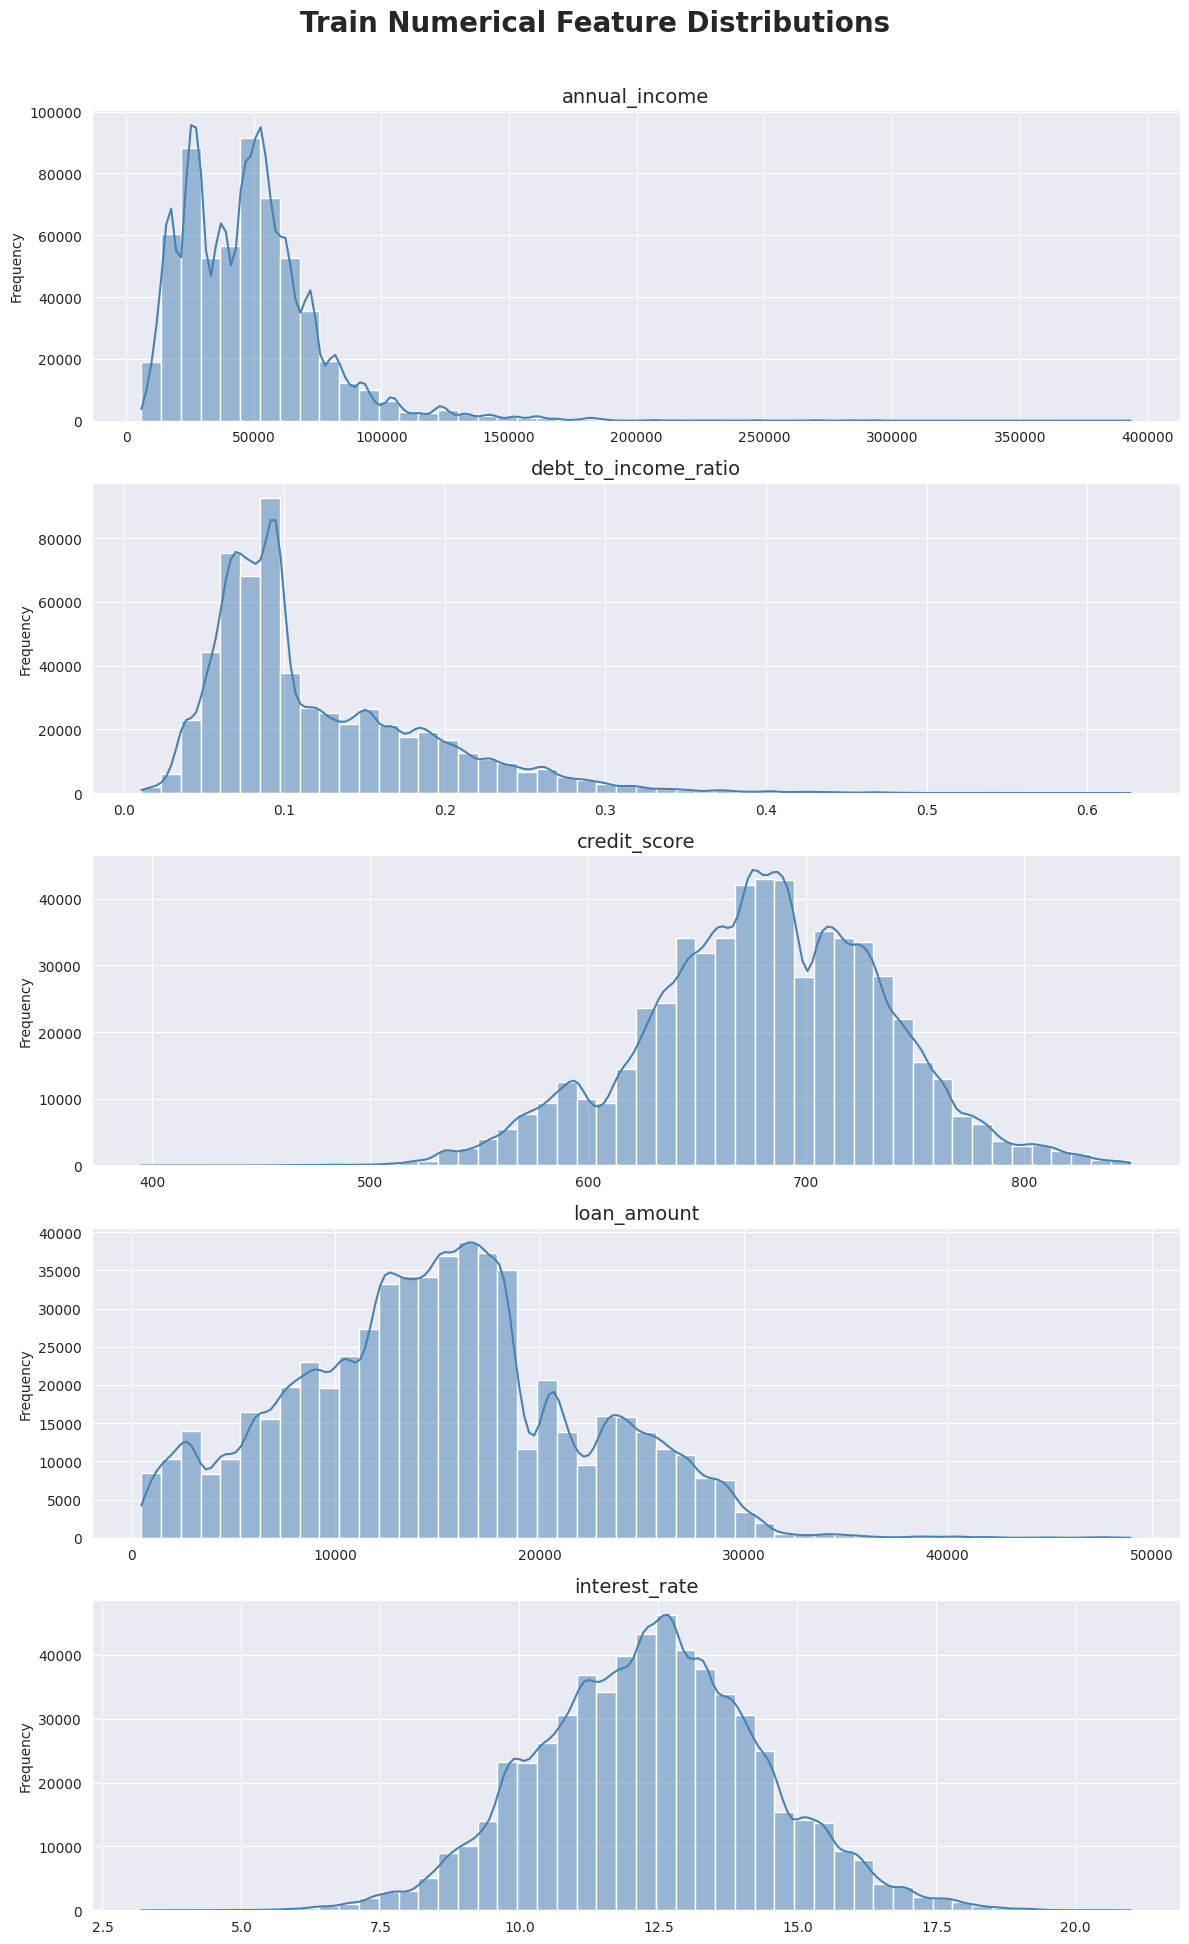

In [9]:
num_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 20))
fig.suptitle('Train Numerical Feature Distributions', fontsize=20, weight='bold')

for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, ax=axes[i], color='steelblue', kde=True, bins=50)
    axes[i].set_title(f'{col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.01, 1, 0.97])
plt.show()

In [10]:
outlier_summary = []
 
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower) | (train[col] > upper)][col]
    
    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier Ratio (%)': round(100 * len(outliers) / len(train), 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Ratio (%)
0,annual_income,27934.40,60981.32,33046.92,-21635.98,110551.70,15917,2.68
1,debt_to_income_ratio,0.07,0.16,0.08,-0.05,0.28,17556,2.96
2,credit_score,646.00,719.00,73.00,536.50,828.50,5901,0.99
3,loan_amount,10279.62,18858.58,8578.96,-2588.82,31727.02,2902,0.49
4,interest_rate,10.99,13.68,2.69,6.96,17.72,5136,0.86


In [11]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

skew_kurt_summary = []

for col in numeric_cols:
    skew_kurt_summary.append({
        'Variable': col,
        'Skewness': round(train[col].skew(), 3),
        'Kurtosis': round(train[col].kurt(), 3)
    })

skew_kurt_df = pd.DataFrame(skew_kurt_summary).sort_values(by='Skewness', ascending=False).reset_index(drop=True)
skew_kurt_df

,Variable,Skewness,Kurtosis
0,annual_income,1.720,7.091
1,debt_to_income_ratio,1.407,2.335
2,loan_amount,0.207,-0.150
3,interest_rate,0.050,0.060
4,id,0.000,-1.200
5,credit_score,-0.167,0.096
6,loan_paid_back,-1.491,0.223


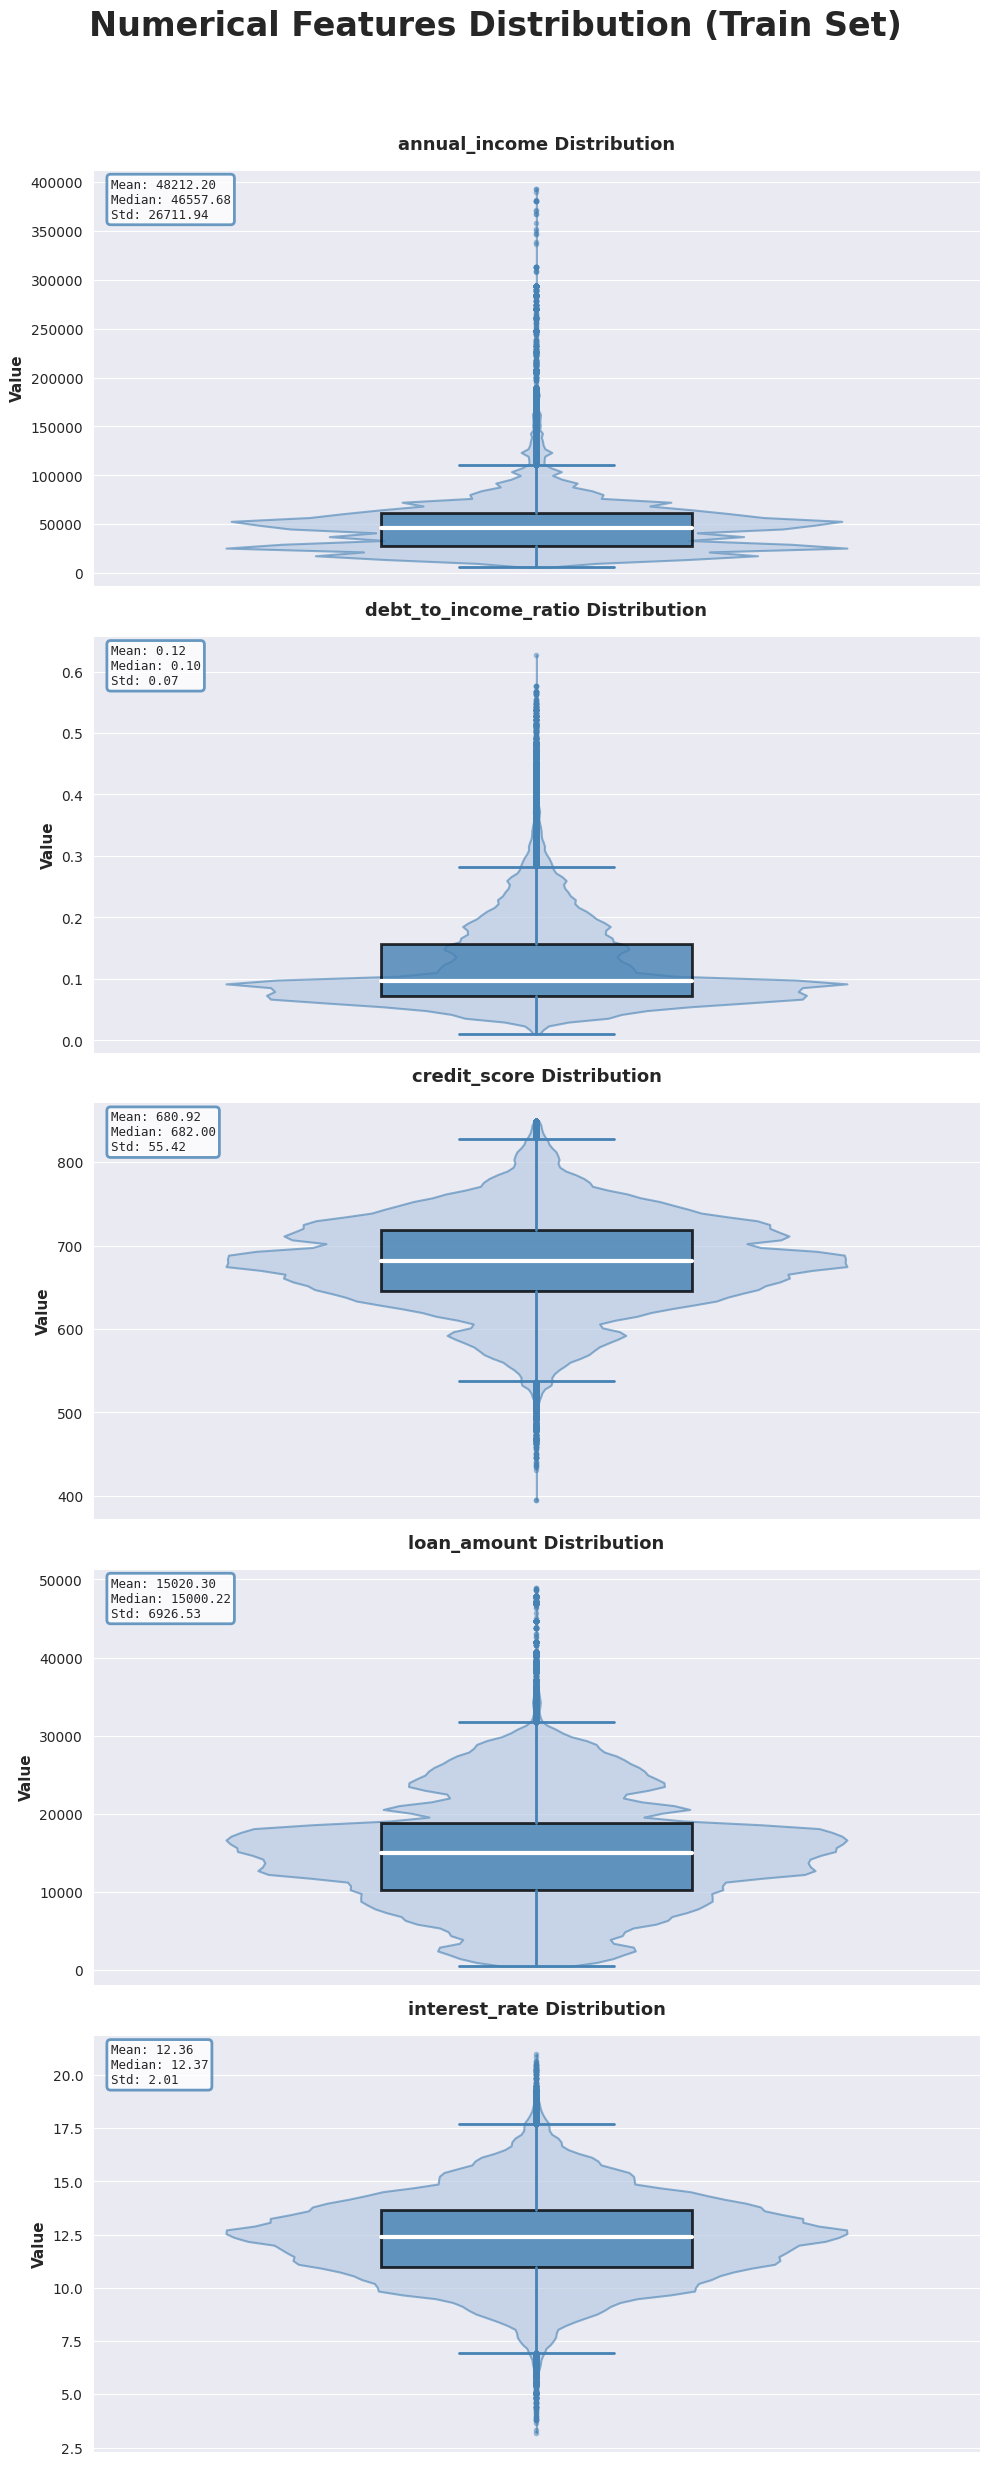

In [12]:
sns.set_style('darkgrid')
train_color = 'steelblue'       
train_violin = 'lightsteelblue'   
 
fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 5 * len(num_cols)))
fig.suptitle('Numerical Features Distribution (Train Set)', 
             fontsize=24, weight='bold', y=0.995)
 
if len(num_cols) == 1:
    axes = [axes]
 
for i, col in enumerate(num_cols):
    
    ax_train = axes[i]   
 
    parts_train = ax_train.violinplot(
        [train[col].dropna()], positions=[0], 
        widths=0.7, showmeans=False, 
        showmedians=False, showextrema=False
    )
    for pc in parts_train['bodies']:
        pc.set_facecolor(train_violin)
        pc.set_alpha(0.6)
        pc.set_edgecolor(train_color)
        pc.set_linewidth(1.5)
 
    bp_train = ax_train.boxplot(
        [train[col].dropna()], positions=[0], 
        widths=0.35, patch_artist=True,
        boxprops=dict(facecolor=train_color, alpha=0.8, linewidth=2),
        whiskerprops=dict(color=train_color, linewidth=2),
        capprops=dict(color=train_color, linewidth=2),
        medianprops=dict(color='white', linewidth=3), 
        flierprops=dict(marker='o', markerfacecolor=train_color, 
                       markersize=4, alpha=0.5, markeredgecolor='none')
    )
    ax_train.set_title(f'{col} Distribution', fontsize=13, weight='bold', pad=15)
    ax_train.set_ylabel('Value', fontsize=11, weight='bold')
    ax_train.set_xticks([])  
    train_stats = train[col].describe()
    stats_text_train = f"Mean: {train_stats['mean']:.2f}\nMedian: {train_stats['50%']:.2f}\nStd: {train_stats['std']:.2f}"
 
    ax_train.text(0.02, 0.98, stats_text_train, transform=ax_train.transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=train_color, linewidth=2),
                  fontfamily='monospace')
 
plt.tight_layout(rect=[0, 0.01, 1, 0.97]) 
plt.show()

<div style="text-align: center; background-color: #e0e0e0; border: 2px solid #888888; border-radius: 10px; padding: 15px; margin: 20px 0;">
  <h2 style="color: #222222; font-family: Arial, sans-serif;">2.  Feature Engineering</h2>
</div>

In [13]:
train_id = train['id'].copy()
test_id = test['id'].copy()
y = train['loan_paid_back'].copy()

train = train.drop(columns=['id', 'loan_paid_back'])
test = test.drop(columns=['id'])

train['grade'] = train['grade_subgrade'].str[0]
train['subgrade'] = train['grade_subgrade'].str[1:].astype(int)
test['grade'] = test['grade_subgrade'].str[0]
test['subgrade'] = test['grade_subgrade'].str[1:].astype(int)

grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
train['grade_encoded'] = train['grade'].map(grade_map)
test['grade_encoded'] = test['grade'].map(grade_map)

cat_cols = ['loan_purpose', 'employment_status', 'education_level', 'marital_status', 'gender', 'grade']

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]]).astype(str)
    le.fit(combined)
    train[col + '_encoded'] = le.transform(train[col].astype(str))
    test[col + '_encoded'] = le.transform(test[col].astype(str))

train['loan_to_income'] = train['loan_amount'] / (train['annual_income'] + 1)
test['loan_to_income'] = test['loan_amount'] / (test['annual_income'] + 1)

train['debt_load'] = train['annual_income'] * train['debt_to_income_ratio']
test['debt_load'] = test['annual_income'] * test['debt_to_income_ratio']

train['credit_utilization'] = train['debt_to_income_ratio'] * train['loan_amount']
test['credit_utilization'] = test['debt_to_income_ratio'] * test['loan_amount']

train['risk_score'] = (train['interest_rate'] / 20) * (train['debt_to_income_ratio'] * 10) * (800 - train['credit_score']) / 100
test['risk_score'] = (test['interest_rate'] / 20) * (test['debt_to_income_ratio'] * 10) * (800 - test['credit_score']) / 100

important_groups = [
    ('loan_purpose_encoded', 'credit_score'),
    ('grade_encoded', 'interest_rate'),
    ('employment_status_encoded', 'annual_income')
]

for cat_col, num_col in important_groups:
    mean_map = train.groupby(cat_col)[num_col].mean().to_dict()
    train[num_col + '_by_' + cat_col + '_mean'] = train[cat_col].map(mean_map)
    test[num_col + '_by_' + cat_col + '_mean'] = test[cat_col].map(mean_map)
    
    train[num_col + '_dev_' + cat_col] = train[num_col] - train[num_col + '_by_' + cat_col + '_mean']
    test[num_col + '_dev_' + cat_col] = test[num_col] - test[num_col + '_by_' + cat_col + '_mean']

train['credit_tier'] = pd.cut(train['credit_score'], bins=[0, 580, 670, 740, 800, 900], labels=[1, 2, 3, 4, 5])
test['credit_tier'] = pd.cut(test['credit_score'], bins=[0, 580, 670, 740, 800, 900], labels=[1, 2, 3, 4, 5])

train['credit_tier'] = train['credit_tier'].fillna(1).astype(int)
test['credit_tier'] = test['credit_tier'].fillna(1).astype(int)

cluster_features = ['annual_income', 'credit_score', 'loan_amount', 'interest_rate', 'debt_to_income_ratio']

scaler_cluster = StandardScaler()
train_scaled = scaler_cluster.fit_transform(train[cluster_features])
test_scaled = scaler_cluster.transform(test[cluster_features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
train['risk_cluster'] = kmeans.fit_predict(train_scaled)
test['risk_cluster'] = kmeans.predict(test_scaled)

train['annual_income_log'] = np.log1p(train['annual_income'])
test['annual_income_log'] = np.log1p(test['annual_income'])

train['debt_ratio_log'] = np.log1p(train['debt_to_income_ratio'])
test['debt_ratio_log'] = np.log1p(test['debt_to_income_ratio'])

freq_cols = ['loan_purpose_encoded', 'grade_encoded', 'employment_status_encoded']
for col in freq_cols:
    freq_map = train[col].value_counts().to_dict()


    train[col + '_freq'] = train[col].map(freq_map)
    test[col + '_freq'] = test[col].map(freq_map).fillna(0)

cols_to_drop = ['grade_subgrade', 'loan_purpose', 'employment_status', 'education_level', 'marital_status', 'gender', 'grade']

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

train.replace([np.inf, -np.inf], np.nan, inplace=True)
test.replace([np.inf, -np.inf], np.nan, inplace=True)

train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (593994, 29)
Test shape: (254569, 29)


<div style="text-align: center; background-color: #e0e0e0; border: 2px solid #888888; border-radius: 10px; padding: 15px; margin: 20px 0;">
  <h2 style="color: #222222; font-family: Arial, sans-serif;">3. Modelling</h2>
</div>

In [14]:
X = train.copy()
X_test = test.copy()

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
models = {
    'LightGBM': LGBMClassifier(
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=8,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        device='gpu',
        verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        tree_method='gpu_hist',
        gpu_id=0,
        eval_metric='auc',
        use_label_encoder=False
    ),
    'CatBoost': CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=3,
        subsample=0.8,
        bootstrap_type='Bernoulli',   
        verbose=0,
        random_state=42,
        task_type='GPU',
        devices='0'
    )
}

oof_preds = {}
test_preds = {}
model_scores = {}

for name, model in models.items():
    oof_fold_preds = np.zeros(len(X))
    test_fold_preds = []

    for train_idx, val_idx in kf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if name == 'LightGBM':
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                           lgb.log_evaluation(0)]
            )
        elif name == 'XGBoost':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      verbose=False)
        elif name == 'CatBoost':
            model.fit(X_train, y_train,
                      eval_set=(X_val, y_val),
                      early_stopping_rounds=100,
                      verbose=False)

        oof_fold_preds[val_idx] = model.predict_proba(X_val)[:,1]
        test_fold_preds.append(model.predict_proba(X_test)[:,1])

    oof_preds[name] = oof_fold_preds
    test_preds[name] = np.mean(test_fold_preds, axis=0)
    model_scores[name] = roc_auc_score(y, oof_fold_preds)

 
weights = pd.Series(model_scores)
weights /= weights.sum()
final_pred = sum(test_preds[m]*w for m,w in weights.items())

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


In [15]:
submission = pd.DataFrame({'id': test_id, 'loan_paid_back': final_pred})
submission.to_csv('submission_final.csv', index=False)
print("Tek final submission kaydedildi: submission_final.csv")
print(submission.head(10))

Tek final submission kaydedildi: submission_final.csv
       id  loan_paid_back
0  593994        0.943106
1  593995        0.980515
2  593996        0.448310
3  593997        0.923082
4  593998        0.959609
5  593999        0.971367
6  594000        0.986967
7  594001        0.968293
8  594002        0.940594
9  594003        0.001907


<div style="text-align: center; background-color: #e0e0e0; border: 2px solid #888888; border-radius: 10px; padding: 15px; margin: 20px 0;">
  <h2 style="color: #222222; font-family: Arial, sans-serif;">4. Results </h2>
</div>

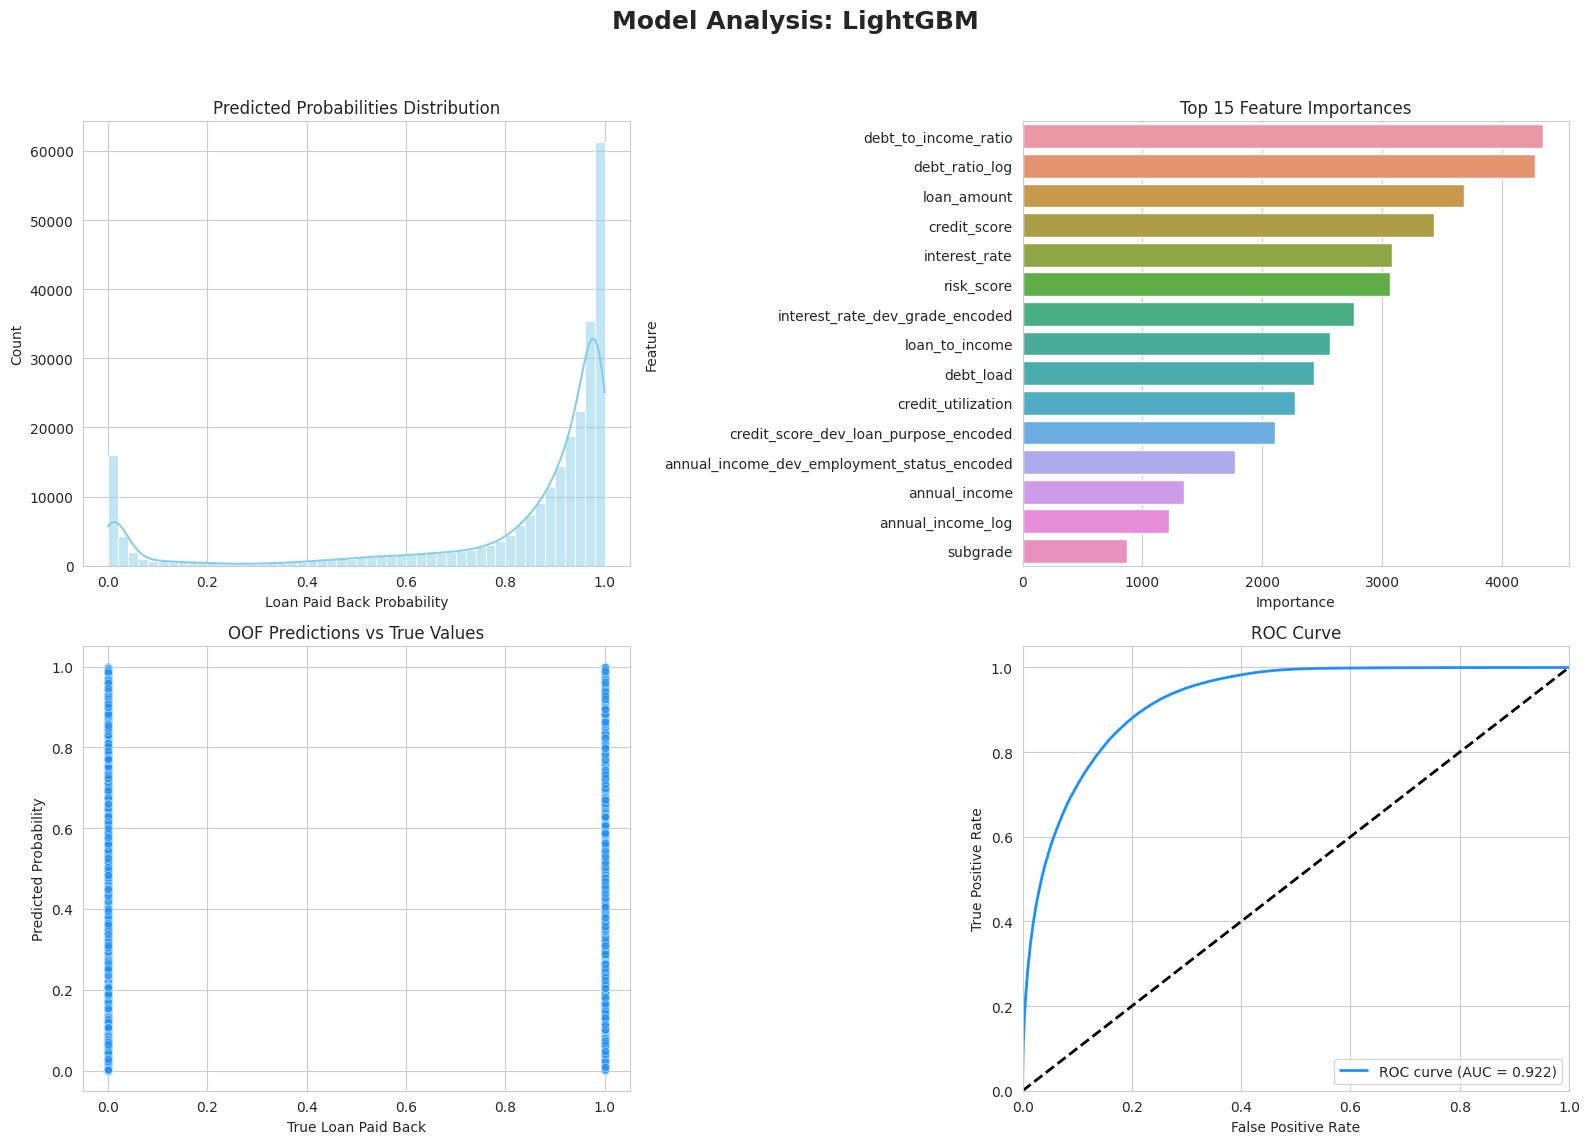

In [16]:
sns.set_style("whitegrid")
sns.set_palette("Blues")

best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]

 
oof = pd.DataFrame({
    'y_true': y,
    'y_pred': oof_preds[best_model_name]
})
 
if best_model_name == 'CatBoost':
    importances = best_model.get_feature_importance()
else:
    importances = best_model.feature_importances_

fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(15)

 
preds = submission['loan_paid_back']

 
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y, oof_preds[best_model_name])
roc_auc = auc(fpr, tpr)

 
fig, axs = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle(f'Model Analysis: {best_model_name}', fontsize=18, fontweight='bold')

 
sns.histplot(preds, bins=50, kde=True, ax=axs[0,0], color='skyblue')
axs[0,0].set_title('Predicted Probabilities Distribution')
axs[0,0].set_xlabel('Loan Paid Back Probability')
axs[0,0].set_ylabel('Count')

 
sns.barplot(x='Importance', y='Feature', data=fi_df, ax=axs[0,1])
axs[0,1].set_title('Top 15 Feature Importances')

 
sns.scatterplot(x='y_true', y='y_pred', data=oof, alpha=0.5, ax=axs[1,0], color='dodgerblue')
axs[1,0].set_title('OOF Predictions vs True Values')
axs[1,0].set_xlabel('True Loan Paid Back')
axs[1,0].set_ylabel('Predicted Probability')

 
axs[1,1].plot(fpr, tpr, color='dodgerblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axs[1,1].plot([0,1],[0,1],'k--', lw=2)
axs[1,1].set_xlim([0.0,1.0])
axs[1,1].set_ylim([0.0,1.05])
axs[1,1].set_xlabel('False Positive Rate')
axs[1,1].set_ylabel('True Positive Rate')
axs[1,1].set_title('ROC Curve')
axs[1,1].legend(loc='lower right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()